In [1]:
# Importing Libraries

import pandas as pd 
import numpy as np 
import tensorflow.keras.backend as K
import tensorflow.keras.layers as layers
from tensorflow.keras.callbacks import Callback, ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

In [2]:
# Loading DataFrames from kaggle directories

df = pd.read_csv("/kaggle/input/competitions/rohlik-sales-forecasting-challenge-v2/sales_train.csv")
inventory = pd.read_csv("/kaggle/input/competitions/rohlik-sales-forecasting-challenge-v2/inventory.csv") 
calendar = pd.read_csv("/kaggle/input/competitions/rohlik-sales-forecasting-challenge-v2/calendar.csv")
df.head()

,unique_id,date,warehouse,total_orders,sales,sell_price_main,availability,type_0_discount,type_1_discount,type_2_discount,type_3_discount,type_4_discount,type_5_discount,type_6_discount
0,4845,2024-03-10,Budapest_1,6436.0,16.34,646.26,1.00,0.00000,0.0,0.0,0.0,0.15312,0.0,0.0
1,4845,2021-05-25,Budapest_1,4663.0,12.63,455.96,1.00,0.00000,0.0,0.0,0.0,0.15025,0.0,0.0
2,4845,2021-12-20,Budapest_1,6507.0,34.55,455.96,1.00,0.00000,0.0,0.0,0.0,0.15025,0.0,0.0
3,4845,2023-04-29,Budapest_1,5463.0,34.52,646.26,0.96,0.20024,0.0,0.0,0.0,0.15312,0.0,0.0
4,4845,2022-04-01,Budapest_1,5997.0,35.92,486.41,1.00,0.00000,0.0,0.0,0.0,0.15649,0.0,0.0


In [3]:
# Coverting date columns to datetime

calendar.date = pd.to_datetime(calendar.date)
df.date = pd.to_datetime(df.date)
calendar = calendar[calendar.date >= df.date.min()]

In [4]:
# Warehouse mapping dictionary, used to encode warehouse

wh_map = {
    'Budapest_1' : 6,
    'Prague_1' : 0, 
    'Prague_3' : 1, 
    'Prague_2' : 2,
    'Brno_1' : 3,
    'Munich_1' : 4, 
    'Frankfurt_1' : 5 
} 

In [5]:
# holiday fill null
calendar["holiday_name"] = calendar["holiday_name"].fillna("") 
del calendar["holiday_name"] # temporarily deleted

# warehouse mapping
calendar["warehouse"] = calendar["warehouse"].map(wh_map)
df["warehouse"] = df["warehouse"].map(wh_map)
inventory["warehouse"] = inventory["warehouse"].map(wh_map)

# get date columns 
calendar["day"] = calendar["date"].dt.day 
calendar["month"] = calendar["date"].dt.month
calendar["year"] = calendar["date"].dt.year - 2020 
calendar["dayNumFromStart"] = calendar["date"].rank(method = "dense")
calendar["dayOfYear"] = calendar.date.dt.dayofyear 
calendar["dayOfWeek"] = calendar.date.dt.dayofweek 
calendar["weekOfYear"] = calendar.date.dt.isocalendar().week

In [6]:
# For each categorical column, creating a dict which holds encoded values based upon 
# Category Name and then Numeric value associated with it. 

# For example: 
# A_1, A_2, A_21, B_1 will have encoding as 
# 1  , 2  , 3   , 4

cols = ["name", "L2_category_name_en", "L3_category_name_en", "L4_category_name_en"]
LCatDict = {} 
for col in cols:
    x = inventory[col].unique()
    _list = sorted(
            x,
            key = lambda z: (z.split("_")[0], int(z.split("_")[-1]))
              )

    LCatDict[col] = { k:v for v, k in enumerate(_list)} 

    inventory[col] = inventory[col].map(LCatDict[col])

In [7]:
# L1 Category mapping

l1_map = {'Bakery' : 0, 'Fruit and vegetable' : 1, 'Meat and fish' : 2}
inventory["L1_category_name_en"] = inventory["L1_category_name_en"].map(l1_map)
inventory.head()

,unique_id,product_unique_id,name,L1_category_name_en,L2_category_name_en,L3_category_name_en,L4_category_name_en,warehouse
0,5255,2583,1761,0,5,5,0,1
1,4948,2426,1200,1,28,102,10,1
2,2146,1079,316,1,19,94,29,0
3,501,260,807,2,38,138,50,0
4,4461,2197,898,1,25,80,10,5


In [8]:
# Joining Sales and Inventory based upon key(unique_id)

train = pd.merge(
    df, 
    inventory, 
    how = "left", 
    on = "unique_id"
)

train.drop(columns = ["warehouse_y"], axis = 1, inplace = True) 
train.rename(columns = {"warehouse_x": "warehouse"}, inplace = True)


# Joining Train with Calendar, based upon key(date, warehouse)
# NOTE: joining based upon date will going to create many to many relationship, which will produce undesirable results

train = pd.merge(
    train, 
    calendar, 
    how = "left", 
    on = ["date", "warehouse"]
)

In [9]:
# Sorting Train by unique_id then date, as it will be used in finding previous days sales for a product

train.sort_values(by = ["unique_id", "date",], inplace = True) 

In [10]:
train.head()

,unique_id,date,warehouse,total_orders,sales,sell_price_main,availability,type_0_discount,type_1_discount,type_2_discount,...,shops_closed,winter_school_holidays,school_holidays,day,month,year,dayNumFromStart,dayOfYear,dayOfWeek,weekOfYear
3910978,0,2022-07-18,6,5289.0,3.97,710.89,0.09,0.0,0.0,0.00000,...,0,0,0,18,7,2,717.0,199,0,29
3910983,0,2022-07-19,6,5255.0,73.36,710.89,1.00,0.0,0.0,0.00000,...,0,0,0,19,7,2,718.0,200,1,29
3910959,0,2022-07-20,6,5334.0,558.09,710.89,0.96,0.0,0.0,0.45045,...,0,0,0,20,7,2,719.0,201,2,29
3910961,0,2022-07-21,6,5459.0,14.03,710.89,0.06,0.0,0.0,0.45045,...,0,0,0,21,7,2,720.0,202,3,29
3910956,0,2022-07-22,6,5461.0,558.53,710.89,0.97,0.0,0.0,0.45045,...,0,0,0,22,7,2,721.0,203,4,29


In [11]:
# Previous n lags will be fetched for each column in cols

lags = [1, 2, 3, 5, 7, 14, 21, 28] 
cols = ["sales", "sell_price_main", "type_0_discount", "total_orders"]

for col in cols: 
    for n in lags: 

        tmp = train[col].shift(n) 
        uid = train["unique_id"].shift(n) 
        train[f"prev_{n}_flag"] = (uid == train["unique_id"])
        train[f"prev_{n}_{col}"] = tmp

        if col == "sales" and n>1: 
            roll = train[col].shift(1).rolling(n)
            train[f"prev_{n}_{col}_mean"] = roll.mean() * train[f"prev_{n}_flag"]
            train[f"prev_{n}_{col}_median"] = roll.median() * train[f"prev_{n}_flag"]
            train[f"prev_{n}_{col}_std"] = roll.std() * train[f"prev_{n}_flag"] 

            if n>2:
                train[f"prev_{n}_{col}_max"] = roll.max() * train[f"prev_{n}_flag"] 
                train[f"prev_{n}_{col}_min"] = roll.min() * train[f"prev_{n}_flag"] 

        # Not going to remove them as it will provide our model with following info
        # previous n record does not belong to same product
        
        # if n != 1:
        #    del train[f"prev_{n}_flag"]

In [12]:
# Lets check how many columns we have now

train.shape

(4007419, 104)

In [13]:
# Creating custom Data Generator which will return batched data used for training by tensorflow models

class DataGenerator(tf.keras.utils.Sequence): 
    def __init__(self, X, y, batch_size, steps, shuffle = False): 
        self.X = X 
        self.y = y
        self.batch_size = batch_size 
        self.steps = steps 
        self.n = len(self.X)
        self.num_features = self.X.shape[-1]
        self.shuffle = shuffle
        self.on_epoch_end()

    
    def on_epoch_end(self): 
        self.indexes = [i for i in range(self.steps-1, self.n)] # skipping first steps-2 records
        if self.shuffle:
            np.random.shuffle(self.indexes)

    
    def __len__(self): 
        return (self.n - self.steps + 1) // self.batch_size 


    def __getitem__(self, index): # this gets current batch num ie, len // batch_size
        
        _start = index * self.batch_size
        _last = (index + 1) * self.batch_size

        return self.data_generation(_start, _last)

    
    def data_generation(self, _start, _last): 

        X, y = (
            np.zeros([self.batch_size, self.steps, self.num_features]),
            np.zeros([self.batch_size,  1])
        )

        for _, idx in enumerate(range(_start, _last)): 

            X[_] = self.X[self.indexes[idx] - self.steps + 1 : self.indexes[idx] + 1]
            y[_] = self.y[self.indexes[idx]] 

        return X, y

In [14]:
train.fillna(-100, inplace = True)
train.reset_index(drop = True, inplace = True)

In [15]:
train["date"].max()

Timestamp('2024-06-02 00:00:00')

In [16]:
Xdf = train[train["date"]<= '2024-05-19'].copy()
Xdf.drop(columns = ["date", "availability"], axis = 1, inplace = True)

In [17]:
valid_df = train[(train["date"] >='2024-05-14')].copy()
valid_df.drop(columns = ["date", "availability"], axis = 1, inplace = True)

In [18]:
sc = {} 
for col in Xdf: 
    if col != 'sales': 
        _ = StandardScaler()
        sc[col] = _.fit(Xdf[col].values.reshape(-1, 1))
        Xdf[col] = sc[col].transform(Xdf[col].values.reshape(-1, 1)).reshape(-1)
        valid_df[col] = sc[col].transform(valid_df[col].values.reshape(-1, 1)).reshape(-1)

In [19]:
valid_df.shape[0] / Xdf.shape[0]

0.01705739754046615

In [20]:
sum(train.isna().sum()>0)

0

In [21]:
# LSTM Model Architecture

def LSTM_Model(num_columns, num_labels, hidden_units, batch_size, steps, dropout_rates, learning_rate):

    inp = tf.keras.layers.Input(shape = (steps, num_columns))
    x = tf.keras.layers.LSTM(
        128, 
        #input_shape = (steps, num_columns),
        return_sequences = True, 
        name = "lstm_1"
    )(inp)
    
    x = tf.keras.layers.GaussianNoise(.08, seed = 42)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(dropout_rates)(x)
    
    x = tf.keras.layers.LSTM(
        128, 
        #input_shape = (steps, num_columns, ),
        name = "lstm_2"
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(dropout_rates)(x) 

    x = tf.keras.layers.Dense(256)(x)
    x = tf.keras.layers.Activation("swish")(x)
    x = tf.keras.layers.Dropout(dropout_rates)(x)  
    x = tf.keras.layers.Dense(128)(x)
    x = tf.keras.layers.Activation("swish")(x)
    x = tf.keras.layers.Dropout(dropout_rates)(x)  
    x = tf.keras.layers.Dense(64)(x)
    x = tf.keras.layers.Activation("swish")(x)
    out = tf.keras.layers.Dense(num_labels)(x)
    #out = tf.keras.layers.Activation('linear')(x)
    
    model = tf.keras.models.Model(inputs = inp, outputs = out)
    model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate = learning_rate),
                loss = tf.keras.losses.MeanAbsoluteError() ,
                      #steps_per_execution = 32
                      #metrics = ["mae"], 
                     )
    return model

# GRU Model Architecture

def GRU_Model(num_columns, num_labels, hidden_units, batch_size, steps, dropout_rates, learning_rate):

    inp = tf.keras.layers.Input(shape = (steps, num_columns))
    x = tf.keras.layers.GRU(
        128, 
        #input_shape = (steps, num_columns),
        return_sequences = True, 
        name = "GRU_1"
    )(inp)
    
    x = tf.keras.layers.GaussianNoise(.08, seed = 42)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(dropout_rates)(x)
    
    x = tf.keras.layers.GRU(
        128, 
        #input_shape = (steps, num_columns, ),
        name = "GRU_2"
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(dropout_rates)(x) 
    x = tf.keras.layers.Dense(256)(x)
    x = tf.keras.layers.Activation("swish")(x)
    x = tf.keras.layers.Dropout(dropout_rates)(x)  
    x = tf.keras.layers.Dense(128)(x)
    x = tf.keras.layers.Activation("swish")(x)
    x = tf.keras.layers.Dropout(dropout_rates)(x)  
    x = tf.keras.layers.Dense(64)(x)
    x = tf.keras.layers.Activation("swish")(x)
    out = tf.keras.layers.Dense(num_labels)(x)
    #out = tf.keras.layers.Activation('linear')(x)
    
    model = tf.keras.models.Model(
        inputs = inp,
        outputs = out
    )
    model.compile(
        optimizer = tf.keras.optimizers.Adam(learning_rate = learning_rate),
        loss = tf.keras.losses.MeanAbsoluteError() ,
                      #steps_per_execution = 32
                      #metrics = ["mae"], 
    )
    return model

In [22]:
# Another Custom Data Generator But this one will be used in validation
# As it will going to predict on all the records 
# whether there will be residual due to NumOfRecords // BatchSize

# For Validation Input Data, make sure it start from First date - (steps - 1) day as starting date 

# For Example: Consider First Validation date is 1-Apr and step size is 7 then
# 1 - (7-1) = 26-March
# So validation data should start from 26-March


class valid_dg(tf.keras.utils.Sequence): 
    def __init__(self, X, y, batch_size, flag, steps): 
        self.X = X
        self.y = y
        self.num_cols = X.shape[-1]
        self.batch_size = batch_size
        self.steps = steps
        self.flag_col = flag
        self.n = sum(self.flag_col==0) ##
        self.batches = self.n // self.batch_size 

        self.indexes = [i for i in (self.X[self.flag_col==0]).index]

        #self.on_epoch_end()
        self.X_to_numpy()

    def X_to_numpy(self): 
        self.X = self.X.to_numpy()

    def on_epoch_end(self): 
        # For validation only, no need to do anything here
        pass 

    def __len__(self): 
        
        self.residual = (self.batches * batch_size < self.n) * 1
        return self.batches + self.residual
            

    def __getitem__(self, index): 

        if index != self.batches:
            _start = index * self.batch_size
            _end = (index+1) * self.batch_size
            
            X = np.zeros((self.batch_size, self.steps, self.num_cols))
            y = np.zeros((self.batch_size, 1))
            
            for i, _ in enumerate(range(_start, _end )):
                idx = self.indexes[_]
                X[i] = self.X[idx - self.steps + 1 : idx+1] 
                y[i] = self.y[idx] 

        else: 
            _start = index * self.batch_size
            _end = self.n

            batch_size = _end - _start ##
            
            X = np.zeros((batch_size, self.steps, self.num_cols))
            y = np.zeros((batch_size, 1))
    
            for i, _ in enumerate(range(_start, _end )):
                idx = self.indexes[_]
                X[i] = self.X[idx - self.steps + 1 : idx+1] 
                y[i] = self.y[idx]  

        return X, y
        

In [23]:
# Defining model parameters

num_columns = Xdf.shape[-1] - 1
num_labels = 1
hidden_units = 0
batch_size = 1024
epochs = 5
steps = 7
dropout_rates = .2
learning_rate = .0001

In [24]:
# Creating generators instances

DG = DataGenerator(
    X = Xdf.drop("sales", axis = 1).to_numpy(), 
    y = Xdf["sales"].to_numpy(), 
    batch_size = batch_size, 
    steps = steps,
    shuffle = True
)

validDG = DataGenerator(
    X = valid_df.drop("sales", axis = 1).to_numpy(), 
    y = valid_df["sales"].to_numpy(), 
    batch_size = batch_size, 
    steps = steps,
    shuffle = False
)

In [25]:
# Making sure First date - (steps - 1) condition is true for validation data

valid = train[(train["date"] >='2024-05-14')].copy()
valid = valid.reset_index(drop = True)
flag = valid["date"] <= "2024-05-19" 
valid.loc[flag]

valid = train[(train["date"] >='2024-05-14')].copy()
valid = valid.reset_index(drop = True)
flag = valid["date"] <= "2024-05-19"
valid.drop(columns = ["availability"], axis = 1, inplace = True)

In [26]:
# Standardizing Training data, necessary for good score and faster training

for col in Xdf: 
    if col != 'sales': 
        _ = sc[col]
        valid[col] = sc[col].transform(valid[col].values.reshape(-1, 1)).reshape(-1)

In [27]:
testGen = valid_dg(
    X = valid.drop(columns = ["date", "sales"], axis = 1),
    y = valid["sales"],
    batch_size = batch_size,
    flag = flag,
    steps = steps
)

In [28]:
# LSTM Model

model = LSTM_Model(
    num_columns, 
    num_labels, 
    hidden_units, 
    batch_size, 
    steps, 
    dropout_rates, 
    learning_rate
)

I0000 00:00:1785154416.334483      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [29]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 7, 101)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 7, 128)         │       117,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise (GaussianNoise)  │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 324,609 (1.24 MB)

 Trainable params: 324,097 (1.24 MB)

 Non-trainable params: 512 (2.00 KB)

In [30]:
# Checkpoint path where best model's weight is stored
ckp_path = f'LSTM{0}.weights.h5'

# Callbacks 
rlr = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.3, patience = 3, verbose = 0, 
                    min_delta = 1e-2, mode = 'min')

ckp = ModelCheckpoint(ckp_path, monitor = 'val_loss', verbose = 0, 
                   save_best_only = True, save_weights_only = True, mode = 'min')

es = EarlyStopping(monitor = 'val_loss', min_delta = 1e-2, patience = 5, mode = 'min', 
               baseline = None, restore_best_weights = True, verbose = 0)

# Training our LSTM model
model.fit(
    DG,
    validation_data = testGen,
    epochs = epochs, 
    callbacks = [rlr, ckp, es],
    verbose = 1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
3867/3867 ━━━━━━━━━━━━━━━━━━━━ 62s 15ms/step - loss: 31.4162 - val_loss: 21.9950 - learning_rate: 1.0000e-04
Epoch 2/5
3867/3867 ━━━━━━━━━━━━━━━━━━━━ 55s 14ms/step - loss: 23.8515 - val_loss: 20.5999 - learning_rate: 1.0000e-04
Epoch 3/5
3867/3867 ━━━━━━━━━━━━━━━━━━━━ 55s 14ms/step - loss: 22.7698 - val_loss: 20.3282 - learning_rate: 1.0000e-04
Epoch 4/5
3867/3867 ━━━━━━━━━━━━━━━━━━━━ 55s 14ms/step - loss: 22.1736 - val_loss: 20.2731 - learning_rate: 1.0000e-04
Epoch 5/5
3867/3867 ━━━━━━━━━━━━━━━━━━━━ 55s 14ms/step - loss: 21.7978 - val_loss: 19.4589 - learning_rate: 1.0000e-04


In [31]:
# Getting prediction from LSTM model

lstm_preds = model.predict(testGen)

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [32]:
import torch , gc 
del model
gc.collect()
torch.cuda.empty_cache()

In [33]:
# GRU Model

ckp_path = f'GRU{0}.weights.h5'

model = GRU_Model(
    num_columns, 
    num_labels, 
    hidden_units, 
    batch_size, 
    steps, 
    dropout_rates, 
    learning_rate
)

rlr = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.3, patience = 3, verbose = 0, 
                    min_delta = 1e-2, mode = 'min')

ckp = ModelCheckpoint(ckp_path, monitor = 'val_loss', verbose = 0, 
                   save_best_only = True, save_weights_only = True, mode = 'min')

es = EarlyStopping(monitor = 'val_loss', min_delta = 1e-2, patience = 5, mode = 'min', 
               baseline = None, restore_best_weights = True, verbose = 0)

model.fit(
    DG,
    validation_data = testGen,
    epochs = epochs, 
    callbacks = [rlr, ckp, es],
    verbose = 1
)

Epoch 1/5
3867/3867 ━━━━━━━━━━━━━━━━━━━━ 59s 14ms/step - loss: 32.7378 - val_loss: 21.9753 - learning_rate: 1.0000e-04
Epoch 2/5
3867/3867 ━━━━━━━━━━━━━━━━━━━━ 56s 14ms/step - loss: 23.7869 - val_loss: 20.6311 - learning_rate: 1.0000e-04
Epoch 3/5
3867/3867 ━━━━━━━━━━━━━━━━━━━━ 56s 14ms/step - loss: 22.7373 - val_loss: 20.2621 - learning_rate: 1.0000e-04
Epoch 4/5
3867/3867 ━━━━━━━━━━━━━━━━━━━━ 55s 14ms/step - loss: 22.1764 - val_loss: 19.8922 - learning_rate: 1.0000e-04
Epoch 5/5
3867/3867 ━━━━━━━━━━━━━━━━━━━━ 55s 14ms/step - loss: 21.7924 - val_loss: 19.7405 - learning_rate: 1.0000e-04


In [34]:
# GRU model's predictions

gru_preds = model.predict(testGen)

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [35]:
valid.loc[flag==0, "gru"] = gru_preds
valid.loc[flag==0, "lstm"] = lstm_preds

/tmp/ipykernel_58/3378298202.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  valid.loc[flag==0, "gru"] = gru_preds
/tmp/ipykernel_58/3378298202.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  valid.loc[flag==0, "lstm"] = lstm_preds


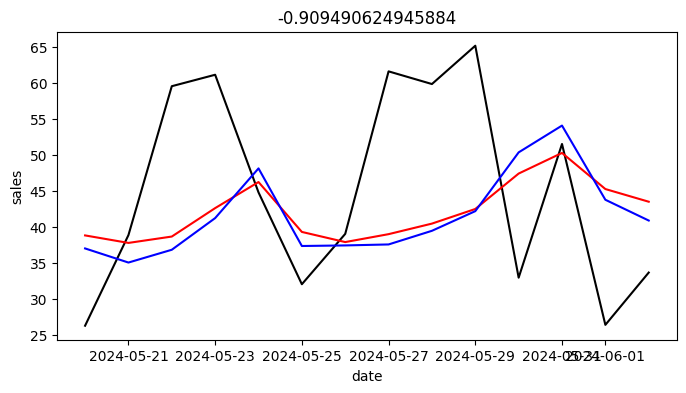

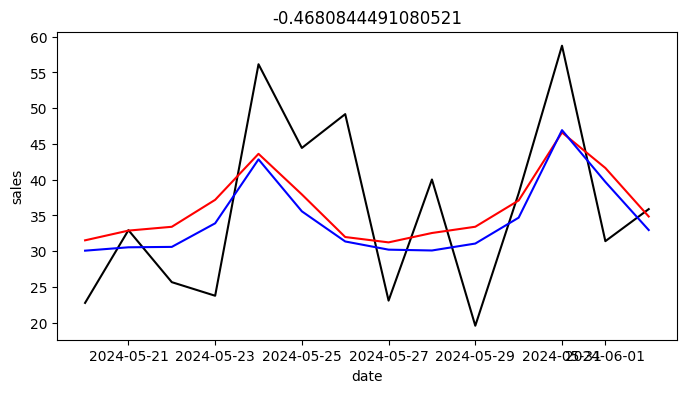

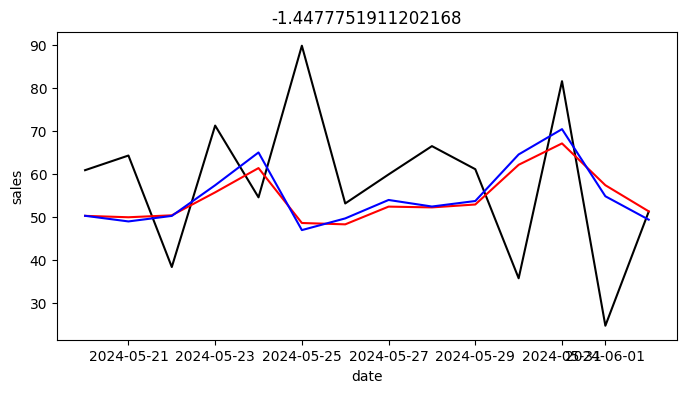

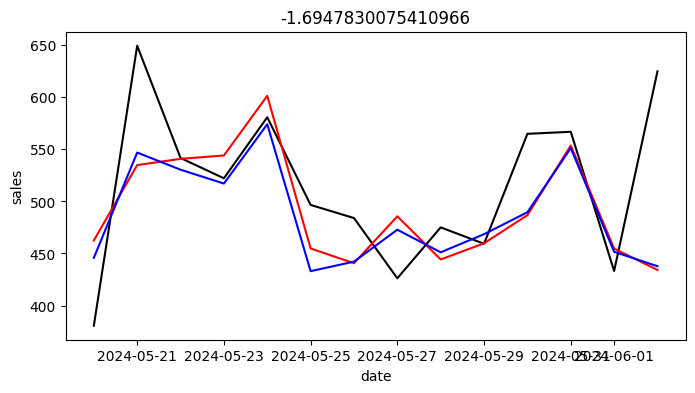

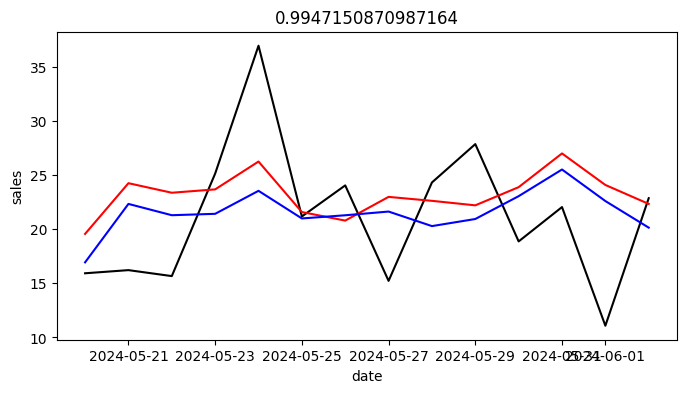

In [36]:
# Comparing 5 random Unique_id's predictions from both LSTM and GRU with True Labels

import random 
import seaborn as sns 
import matplotlib.pyplot as plt 

ids = random.sample(sorted(valid["unique_id"].unique()), 5) 

for ID in ids: 
    fig, ax = plt.subplots(figsize = (8, 4))
    sns.lineplot(valid[(flag==0) & (valid["unique_id"] == ID)], x = "date", y = "sales", color = "black", errorbar = None) 
    sns.lineplot(valid[(flag==0) & (valid["unique_id"] == ID)], x = "date", y = "lstm", color = "red", errorbar = None)
    sns.lineplot(valid[(flag==0) & (valid["unique_id"] == ID)], x = "date", y = "gru", color = "blue", errorbar = None)
    plt.title(ID)
    fig.show()


In [37]:
from sklearn.metrics import mean_absolute_error

lstm_score = mean_absolute_error(
    valid.loc[flag[flag==False].index]["sales"],
    lstm_preds,
) 

gru_score = mean_absolute_error(
    valid.loc[flag[flag==False].index]["sales"],
    gru_preds,
)

19.458896814981493

In [40]:
# Let's see weighted ensemble helps in decreasing MAE or not

mean_absolute_error(
    valid[flag==0]["sales"],
    (lstm_preds*1.15 + gru_preds*.85) / 2,
)

19.17561154760339